In [49]:
# Ashwin R. Rao
# CSC478-701
# Final Project

In [146]:
# Imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn import tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, SGDRegressor, ElasticNetCV, RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split as TTS, GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse
from sklearn.tree import DecisionTreeClassifier

In [51]:
# Set pandas to show all columns
pd.set_option('display.max_columns', 500)

In [52]:
# Suppress future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### __CSC478-701 Final Project__
### __by Ashwin R. Rao__
# __Kickstarter Campaign Analysis to Predict Outcome & the Percent of Fundraising Goal to be Raised__

### Introduction

The dataset chosen for this analysis contains 66 variables measuring various aspects of Kickstarter fundraising campaigns. Kickstarter is an online crowdfunding platform where novel product ideas are proposed and individual contributors can pay to help make those ideas into a reality. It is a promising concept, and one that has had a ripple effect on the charity industry as a whole. But the sad truth is that over half of kickstarter campaigns fail. It would be helpful to be able to predict, before a campaign ever begins, whether it is likely to fail or succeed. Based on that knowledge, Kickstarters can market their campaigns differently in ways that can be gauged across these 66 variables to help ensure a higher chance of success. It would also be helpful to know _by how much_ campaigns will fail or succeed. Gauging the percent of funds raised relative to the goal would be helpful for Kickstarters to predict how diverse their marketing should be to encourage as many backers as are needed to fill the remainder of the percentage.

This dataset contains information on 20,632 Kickstarter campaigns from as recently as February 1st, 2017. The 66 variables record such features as the project name, blurb, funding goal, funding pledged amount, outcome/state, deadline hour/month/year, and various others. Some aggregate attributes have been included as well which quantify categorical attributes such as name length in number of characters, blurb length, day of week that the campaign ended, etc.

One attribute, `SuccessfulBool`, was identified as the target variable we plan to use for predicting campaign outcomes. It is a binary variable, with a value of 1 indicating success and 0 indicating failure. Since there are only a discrete number of categories for this target variable, supervised classification algorithms such as KNN Classifier and Decision Tree Classifier have been chosen to model the data.

For the secondary target, which is the percentage of the fundraising goal that is/will be achieved by the campaign deadline, a new variable will be produced which is the ratio of `pledged` to `goal` attributes. This secondary target variable will be called `pct_of_goal` and will be continuous. As such, classification is not appropriate and we will need to model the data using regression techniques. Also, it is important to note that this is a multivariate regression problem since our dimensionality exceeds the feature set appropriate for single variable regression such as Ordinary Least Squares. As such, we will try four multivariate techniques: K-Nearest Neighbors (KNN) Regression, Stochastic Gradient Descent Regression, Ridge Regression and Lasso Regression. We will compare the error and accuracies computed for each model, and choose the best one of the four.

---

### Table of Contents

- Preprocessing / Cleaning
- Exploratory Analysis (EDA)
- Campaign Outcome via ...
    - K-Nearest Neighbors
    - Decision Tree
- Percent of Goal via ...
    - K-Nearest Neighbors
    - Stochastic Gradient Descent
    - Ridge Regression
    - Lasso Regression

---

## Preprocessing

__Importing Data__

I partially preprocessed the dataset in Microsoft Excel and deleted empty columns 29-32 (inclusive). I also deleted several columns that contained redundant String data that had already been recoded to integers/floating points in other columns. This reduced the dataset from 66 attributes down to 52. Excel is ideally suited for this initial preprocessing step because of the ability to read data in its native format without needing to convert to a pandas DataFrame object first. We will continue preprocessing from here...

In [53]:
ks = pd.read_csv('./kickstarter_data_partially_processed.csv', index_col=0)

In [54]:
ks.head(1)

,id,name,blurb,goal,pledged,state,slug,disable_communication,country,currency,currency_trailing_code,deadline,state_changed_at,created_at,launched_at,staff_pick,backers_count,static_usd_rate,usd_pledged,spotlight,name_len,name_len_clean,blurb_len,blurb_len_clean,deadline_weekday,state_changed_at_weekday,created_at_weekday,launched_at_weekday,deadline_month,deadline_day,deadline_yr,deadline_hr,state_changed_at_month,state_changed_at_day,state_changed_at_yr,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,create_to_launch_days,launch_to_deadline_days,launch_to_state_change_days,SuccessfulBool,USorGB,TOPCOUNTRY,LaunchedTuesday,DeadlineWeekend
0,1454391034,Auntie Di's Music Time Sign ASL for Hearing an...,MTS ASL Curriculum Workbook is a reproducible ...,1500.0,0.0,failed,auntie-dis-music-time-sign-asl-for-hearing-and...,False,US,USD,True,1/23/15 10:35,1/23/15 10:35,11/29/14 22:55,12/17/14 13:47,False,0,1.0,0.0,False,11.0,9.0,21.0,16.0,Friday,Friday,Saturday,Wednesday,1,23,2015,10,1,23,2015,10,11,29,2014,22,12,17,2014,13,17,36,36,0,1,1,0,0


__Dropping Redundant String Attributes__

We don't actually need the `name`, `blurb` or `slug` attributes since they have been summarized in terms of character length in `name_len`, `name_len_clean` (which skips conjunctions like 'and'), `blurb_len` and `blurb_len_clean`.

Also, we don't need `state` since it has been conveniently recoded to a boolean in `SuccessfulBool`.

In [55]:
ks = ks.drop(['name', 'blurb', 'slug', 'state'], axis=1)

In [56]:
ks.head(1)

,id,goal,pledged,disable_communication,country,currency,currency_trailing_code,deadline,state_changed_at,created_at,launched_at,staff_pick,backers_count,static_usd_rate,usd_pledged,spotlight,name_len,name_len_clean,blurb_len,blurb_len_clean,deadline_weekday,state_changed_at_weekday,created_at_weekday,launched_at_weekday,deadline_month,deadline_day,deadline_yr,deadline_hr,state_changed_at_month,state_changed_at_day,state_changed_at_yr,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,create_to_launch_days,launch_to_deadline_days,launch_to_state_change_days,SuccessfulBool,USorGB,TOPCOUNTRY,LaunchedTuesday,DeadlineWeekend
0,1454391034,1500.0,0.0,False,US,USD,True,1/23/15 10:35,1/23/15 10:35,11/29/14 22:55,12/17/14 13:47,False,0,1.0,0.0,False,11.0,9.0,21.0,16.0,Friday,Friday,Saturday,Wednesday,1,23,2015,10,1,23,2015,10,11,29,2014,22,12,17,2014,13,17,36,36,0,1,1,0,0


The supervised learning algorithms we'll be using in this analysis require quantitative input, so we will want to recode as many of our categorical attributes as possible to capture as much of the original data for training our models.

__Dummy Encoding String Attributes__

`disable_communication`, `currency_trailing_code`, `staff_pick` and `spotlight` are already encoded as String representations of boolean values. We can use pandas to produce their one-hot dummy encodings.

We can also recode `country` and `currency` as they each have multiple categories...

In [57]:
ks = pd.get_dummies(ks, prefix=None, 
                    columns=['country', 'currency', 'disable_communication', \
                             'currency_trailing_code', 'staff_pick', 'spotlight'], 
                    drop_first=True)

In [58]:
ks.head(1)

,id,goal,pledged,deadline,state_changed_at,created_at,launched_at,backers_count,static_usd_rate,usd_pledged,name_len,name_len_clean,blurb_len,blurb_len_clean,deadline_weekday,state_changed_at_weekday,created_at_weekday,launched_at_weekday,deadline_month,deadline_day,deadline_yr,deadline_hr,state_changed_at_month,state_changed_at_day,state_changed_at_yr,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,create_to_launch_days,launch_to_deadline_days,launch_to_state_change_days,SuccessfulBool,USorGB,TOPCOUNTRY,LaunchedTuesday,DeadlineWeekend,country_AU,country_BE,country_CA,country_CH,country_DE,country_DK,country_ES,country_FR,country_GB,country_HK,country_IE,country_IT,country_LU,country_MX,country_NL,country_NO,country_NZ,country_SE,country_SG,country_US,currency_CAD,currency_CHF,currency_DKK,currency_EUR,currency_GBP,currency_HKD,currency_MXN,currency_NOK,currency_NZD,currency_SEK,currency_SGD,currency_USD,disable_communication_True,currency_trailing_code_True,staff_pick_True,spotlight_True
0,1454391034,1500.0,0.0,1/23/15 10:35,1/23/15 10:35,11/29/14 22:55,12/17/14 13:47,0,1.0,0.0,11.0,9.0,21.0,16.0,Friday,Friday,Saturday,Wednesday,1,23,2015,10,1,23,2015,10,11,29,2014,22,12,17,2014,13,17,36,36,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0


It may seem like we have too many country dummy attributes but we may be able to drop some of them with Principal Component Analysis later on.

__More Recoding String DateTime Attributes__

The month, day, year and hour for attributes `deadline`, `state_changed_at`, `created_at` and `launched_at` are encoded in other variables. What is missing is the minutes. It seems like a stretch that the exact minute may have something to do with the outcome of a campaign but we won't know unless we create a variable containing this information and continue with our analysis...

In [59]:
# Function to be called in lambda
def date_to_time(x):
    x = (x.split()[1]).split(':')[1]
    return x

In [60]:
ks['deadline_min'] = pd.to_numeric(ks.apply(lambda x: date_to_time(x['deadline']), axis=1))
ks['state_changed_at_min'] = pd.to_numeric(ks.apply(lambda x: date_to_time(x['state_changed_at']), axis=1))
ks['created_at_min'] = pd.to_numeric(ks.apply(lambda x: date_to_time(x['created_at']), axis=1))
ks['launched_at_min'] = pd.to_numeric(ks.apply(lambda x: date_to_time(x['launched_at']), axis=1))

We can drop the date-time String variables since all information is now encoded elsewhere. We can also drop the String weekday variables since that information has been encoded implicitly in the `..._at_day` variables. And finally we can also probably drop the `id` since it's only function was to identify campaigns but that task is being accomplished by our row indices...

In [61]:
ks = ks.drop(['id', 'deadline_weekday', 'state_changed_at_weekday', \
              'created_at_weekday', 'launched_at_weekday', 'deadline', \
              'state_changed_at', 'created_at', 'launched_at'], axis=1)

In [62]:
ks.head(1)

,goal,pledged,backers_count,static_usd_rate,usd_pledged,name_len,name_len_clean,blurb_len,blurb_len_clean,deadline_month,deadline_day,deadline_yr,deadline_hr,state_changed_at_month,state_changed_at_day,state_changed_at_yr,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,create_to_launch_days,launch_to_deadline_days,launch_to_state_change_days,SuccessfulBool,USorGB,TOPCOUNTRY,LaunchedTuesday,DeadlineWeekend,country_AU,country_BE,country_CA,country_CH,country_DE,country_DK,country_ES,country_FR,country_GB,country_HK,country_IE,country_IT,country_LU,country_MX,country_NL,country_NO,country_NZ,country_SE,country_SG,country_US,currency_CAD,currency_CHF,currency_DKK,currency_EUR,currency_GBP,currency_HKD,currency_MXN,currency_NOK,currency_NZD,currency_SEK,currency_SGD,currency_USD,disable_communication_True,currency_trailing_code_True,staff_pick_True,spotlight_True,deadline_min,state_changed_at_min,created_at_min,launched_at_min
0,1500.0,0.0,0,1.0,0.0,11.0,9.0,21.0,16.0,1,23,2015,10,1,23,2015,10,11,29,2014,22,12,17,2014,13,17,36,36,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,35,35,55,47


Making sure all attributes are quantitative for analysis ...

In [63]:
cols = ks.columns
ind = 0
found = False
for attr in ks.dtypes:
    if(attr == 'object'):
        found = True
        print('{}: {}'.format(cols[ind], attr))
    ind += 1
if(not found):
    print('All attributes are quantitative')

All attributes are quantitative


__Remove/Impute Missing Values__

In [64]:
def check_missing(flag=False):
    ks_miss = ks[['name_len', 'name_len_clean', 'blurb_len', 'blurb_len_clean']]
    for i in ks.columns:
        if(ks[i].isnull().values.any()):
            flag = True
            print('{}:\n{}\n'.format(i, ks[i].isnull().value_counts()))
    if(flag != True):
        print('No missing values')

In [65]:
check_missing()

name_len:
False    20627
True         5
Name: name_len, dtype: int64

name_len_clean:
False    20627
True         5
Name: name_len_clean, dtype: int64

blurb_len:
False    20627
True         5
Name: blurb_len, dtype: int64

blurb_len_clean:
False    20627
True         5
Name: blurb_len_clean, dtype: int64



We could impute the missing values in the above columns by replacing with the mean. But we can also remove the rows since doing so would result in an insignificant loss of data, assuming no overlap between missing rows, of  approximately 0.00097%

In [66]:
ks = ks.dropna(axis=0)

__Creating Secondary Target Attribute: pct_of_goal__

It would also be helpful to be able to predict how much of a campaign's original fundraising goal is met by the deadline of a project. This is similar in a sense to the outcome in that if the percent of goal is less than 100, we can expect the campaign to have failed. But it would be good to know how much money is likely to be raised, nonetheless, ahead of time so that marketing strategies can be tweaked to ensure a higher chance of success. More information is better than less information in this regard, and without being able to predict the amount by which your campaign is likely to fail (according to this model at least), campaign starters are essentially operating in the dark which is never a good thing.

On to the technical part, we can create a new column, `pct_of_goal` which is a ratio of `pledged` (and not `usd_pledged` since we want to be currency-agnostic) to `goal`...

In [67]:
ks['pct_of_goal'] = ks['pledged'] / ks['goal']

We can see below that in campaigns where `pct_of_goal` is 1, `SuccessfulBool` registers True (encoded to 1.0) as well...

In [68]:
ks.where(ks['pct_of_goal'] == 1).dropna()[['goal', 'pledged', 'SuccessfulBool', 'pct_of_goal']].head(10)

,goal,pledged,SuccessfulBool,pct_of_goal
197,500.0,500.0,1.0,1.0
214,2500.0,2500.0,1.0,1.0
293,3800.0,3800.0,1.0,1.0
534,200.0,200.0,1.0,1.0
987,2500.0,2500.0,1.0,1.0
993,3150.0,3150.0,1.0,1.0
1007,800.0,800.0,1.0,1.0
1019,1987.0,1987.0,1.0,1.0
1028,5000.0,5000.0,1.0,1.0
1036,1325.0,1325.0,1.0,1.0


And the opposite, when `pct_of_goal` is not 1, `SuccessfulBool` registers False (encoded to 0.0)...

In [69]:
ks.where(ks['pct_of_goal'] != 1).dropna()[['goal', 'pledged', 'SuccessfulBool', 'pct_of_goal']].head(10)

,goal,pledged,SuccessfulBool,pct_of_goal
0,1500.0,0.0,0.0,0.000000
1,500.0,0.0,0.0,0.000000
2,100000.0,120.0,0.0,0.001200
3,5000.0,0.0,0.0,0.000000
4,3222.0,356.0,0.0,0.110490
5,13000.0,1136.0,0.0,0.087385
6,50000.0,0.0,0.0,0.000000
7,10000.0,0.0,0.0,0.000000
8,6000.0,153.0,0.0,0.025500
9,15000.0,0.0,0.0,0.000000


Now we're ready to start our exploratory analysis ...

---

## Exploratory Data Analysis (EDA)

We want to first plot summary statistics of the data ...

In [70]:
ks.describe()

,goal,pledged,backers_count,static_usd_rate,usd_pledged,name_len,name_len_clean,blurb_len,blurb_len_clean,deadline_month,deadline_day,deadline_yr,deadline_hr,state_changed_at_month,state_changed_at_day,state_changed_at_yr,state_changed_at_hr,created_at_month,created_at_day,created_at_yr,created_at_hr,launched_at_month,launched_at_day,launched_at_yr,launched_at_hr,create_to_launch_days,launch_to_deadline_days,launch_to_state_change_days,SuccessfulBool,USorGB,TOPCOUNTRY,LaunchedTuesday,DeadlineWeekend,country_AU,country_BE,country_CA,country_CH,country_DE,country_DK,country_ES,country_FR,country_GB,country_HK,country_IE,country_IT,country_LU,country_MX,country_NL,country_NO,country_NZ,country_SE,country_SG,country_US,currency_CAD,currency_CHF,currency_DKK,currency_EUR,currency_GBP,currency_HKD,currency_MXN,currency_NOK,currency_NZD,currency_SEK,currency_SGD,currency_USD,disable_communication_True,currency_trailing_code_True,staff_pick_True,spotlight_True,deadline_min,state_changed_at_min,created_at_min,launched_at_min,pct_of_goal
count,2.062700e+04,2.062700e+04,20627.000000,20627.000000,2.062700e+04,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000,20627.000000
mean,9.400197e+04,2.139608e+04,183.708053,1.039360,2.091830e+04,5.940806,5.292578,18.991177,13.081204,6.707471,15.694478,2014.832550,12.926310,6.684346,15.655209,2014.824938,12.856014,6.473021,15.544432,2014.620061,12.673632,6.541087,15.322199,2014.752073,12.416881,49.583313,34.718815,31.174625,0.291754,0.806467,0.816212,0.225190,0.292044,0.032627,0.002472,0.053231,0.004557,0.018277,0.005963,0.008145,0.015126,0.121055,0.001697,0.003830,0.011829,0.000097,0.002666,0.015611,0.003103,0.005381,0.004654,0.001212,0.685412,0.053231,0.004557,0.005963,0.078441,0.121055,0.001697,0.002666,0.003103,0.005381,0.004654,0.001212,0.685412,0.011150,0.795947,0.105929,0.291754,26.938188,26.720657,29.637514,28.324962,3.232841
std,1.335622e+06,1.205115e+05,1222.158106,0.230413,1.154851e+05,2.826118,2.418168,4.632371,3.283547,3.411277,9.027788,1.270495,6.036276,3.448150,9.004034,1.267653,6.023405,3.346035,8.776677,1.274035,5.947070,3.379844,8.801012,1.261851,5.573344,111.106169,11.873524,14.277022,0.454580,0.395076,0.387321,0.417718,0.454714,0.177663,0.049664,0.224500,0.067354,0.133955,0.076992,0.089882,0.122056,0.326199,0.041158,0.061769,0.108119,0.009847,0.051570,0.123966,0.055617,0.073161,0.068064,0.034794,0.464363,0.224500,0.067354,0.076992,0.268871,0.326199,0.041158,0.051570,0.055617,0.073161,0.068064,0.034794,0.464363,0.105008,0.403018,0.307754,0.454580,20.175284,19.767769,17.271926,18.147262,177.339707
min,1.000000e+00,0.000000e+00,0.000000,0.045641,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2009.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.

We see from the above descriptive summary that, first of all, the min and max values vary drastically between variables, indicating a need to normalize the data prior to running our supervised classification algorithms

__Correlational Analysis__

Heatmap visualization of correlation coefficients ...

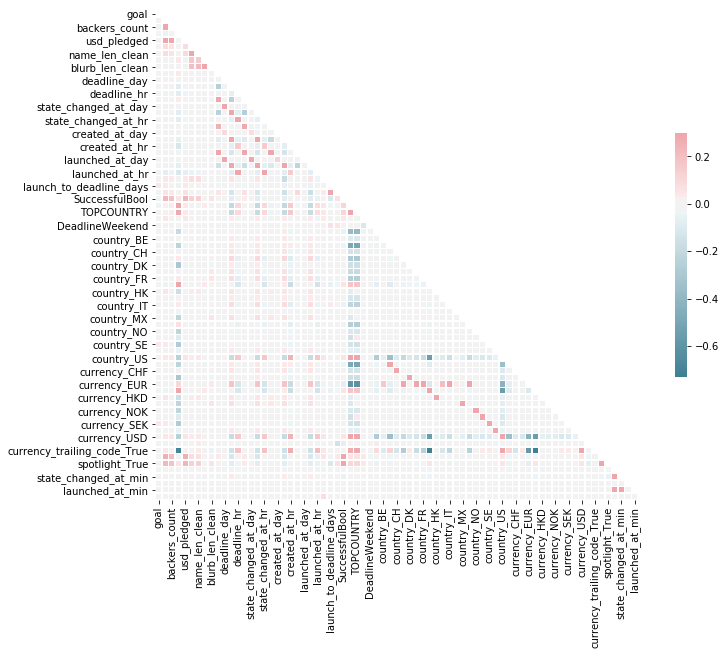

In [71]:
# Generate a mask for the upper triangle
mask = np.zeros_like(ks.corr(method='spearman'), dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(ks.corr(), mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

From the heatmap we can see that time-based variables (those ending in -yr, -hr, -day, -month) are among the strongest correlations for obvious reasons. The deadline of a campaign is clearly going to correlate to the time at which campaign outcome was registered. It's interesting to note that there appears a weakly positive correlation between `SuccessfulBool` (the boolean value indicating success or failure of a campaign) and the dollar amount pledged. The weak nature of this correlation indicates to me that there is a more complicated relationship between the outcome of a campaign than just how much money was raised.

__Dimensionality Reduction via PCA__

We can use principal component analysis to try and reduce the dimensionality of our data, while aiming to maintain 95% capture of variance. By reducing our dimensions, our models will fit more rapidly to the data. Since we are predicting the classes/values of 2 different target variables, we must reduce dimensionality of each X,y set separately.

In [72]:
orig_dimensions = ks.shape[1]

In [73]:
# Outcome X,y set
X_outcome = ks.drop('SuccessfulBool', axis=1).values
y_outcome = ks['SuccessfulBool'].values

# Pct_of_goal X,y Set
X_pct = ks.drop('pct_of_goal', axis=1).values
y_pct = ks['pct_of_goal'].values

In [74]:
# Normalization of both sets
outcome_scaler = MinMaxScaler()
pog_scaler = MinMaxScaler()
X_outcome = outcome_scaler.fit_transform(X_outcome, y_outcome)
X_pct = pog_scaler.fit_transform(X_pct, y_pct)

__PCA for Outcome Prediction__

In [75]:
# Principal Component Analysis
x_out_pca = PCA().fit(X_outcome)
x_out_pca_transf = x_out_pca.transform(X_outcome)

# Generate variable percentage contributions to overall variance
pct_var = np.round(x_out_pca.explained_variance_ratio_ * 100, decimals=1)
pct_var

array([21.1,  9.7,  7. ,  6.8,  6. ,  5.5,  5.2,  4.4,  4.1,  3.2,  2.5,
        2.3,  2.2,  2.2,  1.9,  1.8,  1.6,  1.5,  1.4,  1.2,  0.9,  0.8,
        0.7,  0.6,  0.5,  0.5,  0.4,  0.4,  0.4,  0.3,  0.3,  0.3,  0.3,
        0.3,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ])

Let's visualize this in a __scree plot__ ...

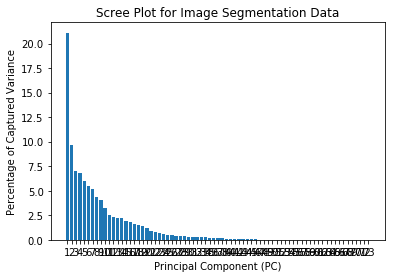

In [76]:
pc_labels = [str(x) for x in range(1, len(pct_var)+1)]
plt.bar(x=range(1, len(pct_var)+1), height=pct_var, width=0.8, tick_label=pc_labels)
plt.xlabel('Principal Component (PC)')
plt.ylabel('Percentage of Captured Variance')
plt.title('Scree Plot for Image Segmentation Data')
plt.show()

From these observations, we can capture only those variables that account for 95% variance in the original data, and transform our original set of predictors ...

In [77]:
# Obtain the variable matrix that captures 95% variance in the original dataset
counter = 0.0
new_x_out = []
for i in pct_var:
    if(counter <= 95.0):
        new_x_out.append(i)
        counter += i

In [78]:
print('{} of {} original variables capture {:.2f}% of variance in the original data'.format(len(new_x_out), 
                                                                                        orig_dimensions-1, 
                                                                                        sum(new_x_out)))

25 of 73 original variables capture 95.10% of variance in the original data


In [79]:
# Principal Component Analysis (with known n_components)
x_out_pca = PCA(n_components=len(new_x_out)).fit(X_outcome)
x_out_pca_transf = x_out_pca.transform(X_outcome)

# Reassign original X_ks variables since we don't need it anymore
X_outcome = x_out_pca_transf

# Generate variable percentage contributions to overall variance
pct_var = np.round(x_out_pca.explained_variance_ratio_ * 100, decimals=1)
pct_var

array([21.1,  9.7,  7. ,  6.8,  6. ,  5.5,  5.2,  4.4,  4.1,  3.2,  2.5,
        2.3,  2.2,  2.2,  1.9,  1.8,  1.6,  1.5,  1.4,  1.2,  0.9,  0.8,
        0.7,  0.6,  0.5])

__Scree Plot (Post-PCA)__

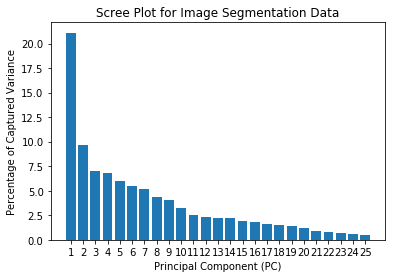

In [80]:
pc_labels = [str(x) for x in range(1, len(pct_var)+1)]
plt.bar(x=range(1, len(pct_var)+1), height=pct_var, width=0.8, tick_label=pc_labels)
plt.xlabel('Principal Component (PC)')
plt.ylabel('Percentage of Captured Variance')
plt.title('Scree Plot for Image Segmentation Data')
plt.show()

__PCA for Percent of Goal Prediction__

In [81]:
# Principal Component Analysis
x_pct_pca = PCA().fit(X_pct)
x_pct_pca_transf = x_pct_pca.transform(X_pct)

# Generate variable percentage contributions to overall variance
pct_var = np.round(x_pct_pca.explained_variance_ratio_ * 100, decimals=1)
pct_var

array([20.1, 11.1,  8.6,  6.5,  6.5,  5.4,  5. ,  4.2,  3.9,  3.1,  2.3,
        2.2,  2.1,  2.1,  1.9,  1.7,  1.5,  1.4,  1.4,  1.1,  0.9,  0.7,
        0.7,  0.6,  0.5,  0.4,  0.4,  0.4,  0.4,  0.3,  0.3,  0.3,  0.3,
        0.3,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ])

Let's visualize this in a __scree plot__ ...

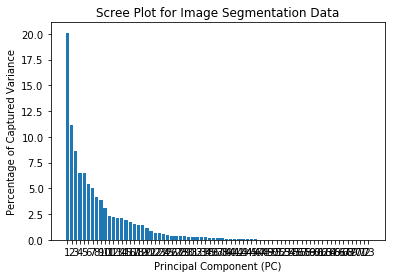

In [82]:
pc_labels = [str(x) for x in range(1, len(pct_var)+1)]
plt.bar(x=range(1, len(pct_var)+1), height=pct_var, width=0.8, tick_label=pc_labels)
plt.xlabel('Principal Component (PC)')
plt.ylabel('Percentage of Captured Variance')
plt.title('Scree Plot for Image Segmentation Data')
plt.show()

From these observations, we can capture only those variables that account for 95% variance in the original data, and transform our original set of predictors ...

In [83]:
# Obtain the variable matrix that captures 95% variance in the original dataset
counter = 0.0
new_x_pct = []
for i in pct_var:
    if(counter <= 95.0):
        new_x_pct.append(i)
        counter += i

In [84]:
print('{} of {} original variables capture {:.2f}% of variance in the original data'.format(len(new_x_pct), 
                                                                                        orig_dimensions-1, 
                                                                                        sum(new_x_pct)))

24 of 73 original variables capture 95.00% of variance in the original data


In [85]:
# Principal Component Analysis (with known n_components)
x_pct_pca = PCA(n_components=len(new_x_pct)).fit(X_pct)
x_pct_pca_transf = x_pct_pca.transform(X_pct)

# Reassign original X_ks variables since we don't need it anymore
X_pct = x_pct_pca_transf

# Generate variable percentage contributions to overall variance
pct_var = np.round(x_pct_pca.explained_variance_ratio_ * 100, decimals=1)
pct_var

array([20.1, 11.1,  8.6,  6.5,  6.5,  5.4,  5. ,  4.2,  3.9,  3.1,  2.3,
        2.2,  2.1,  2.1,  1.9,  1.7,  1.5,  1.4,  1.4,  1.1,  0.9,  0.7,
        0.7,  0.6])

__Scree Plot (Post-PCA)__

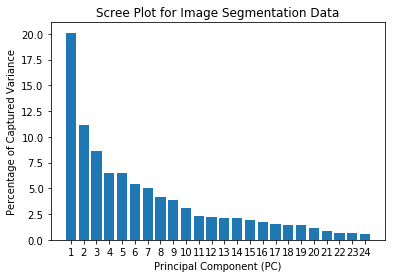

In [86]:
pc_labels = [str(x) for x in range(1, len(pct_var)+1)]
plt.bar(x=range(1, len(pct_var)+1), height=pct_var, width=0.8, tick_label=pc_labels)
plt.xlabel('Principal Component (PC)')
plt.ylabel('Percentage of Captured Variance')
plt.title('Scree Plot for Image Segmentation Data')
plt.show()

__Holdout Partitioning__

For each set of predictors and target variables, we will hold out 20% of the data for testing/validation, and retain 80% for training our models ...

In [87]:
X_outcome_train, X_outcome_test, y_outcome_train, y_outcome_test = TTS(X_outcome, y_outcome, test_size=0.2)
X_pog_train, X_pog_test, y_pog_train, y_pog_test = TTS(X_pct, y_pct, test_size=0.2)

We can use our first supervised classification algorithm to predict outcome ...

---
## Predicting Campaign Outcome

### K-Nearest Neighbors Classifier

In [41]:
# Histories for evaluation of optimal model params
training_accuracy, testing_accuracy, errors = list(), list(), list()

# Range of n_neighbors to be tested
n_neighbors_range = range(1, 24)

# Fit models for each n_neighbors in range
for n_neighbors in n_neighbors_range:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_outcome_train, y_outcome_train)
    training_accuracy.append(knn.score(X_outcome_train, y_outcome_train))
    testing_accuracy.append(knn.score(X_outcome_test, y_outcome_test))
    errors.append(mae(y_outcome_test, knn.predict(X_outcome_test)))

__Visualizing Training, Testing Accuracies__

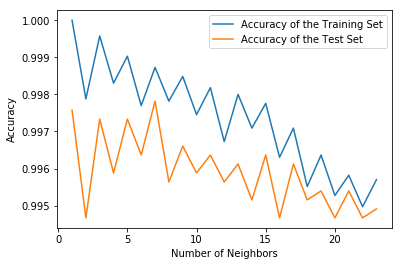

In [42]:
plt.plot(n_neighbors_range, training_accuracy, label='Accuracy of the Training Set')
plt.plot(n_neighbors_range, testing_accuracy, label='Accuracy of the Test Set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()

__Visualizing Mean Absolute Error__

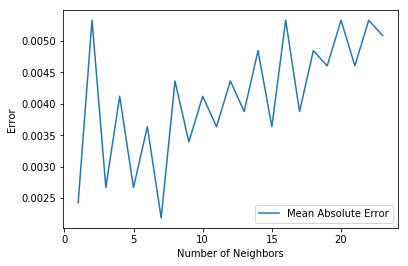

In [43]:
plt.plot(n_neighbors_range, errors, label='Mean Absolute Error')
plt.ylabel('Error')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()

In [45]:
testing_accuracy

[0.9975763451284537,
 0.9946679592825982,
 0.9973339796412991,
 0.9958797867183713,
 0.9973339796412991,
 0.9963645176926805,
 0.9978187106156083,
 0.9956374212312167,
 0.9966068831798351,
 0.9958797867183713,
 0.9963645176926805,
 0.9956374212312167,
 0.9961221522055259,
 0.9951526902569074,
 0.9963645176926805,
 0.9946679592825982,
 0.9961221522055259,
 0.9951526902569074,
 0.9953950557440621,
 0.9946679592825982,
 0.9953950557440621,
 0.9946679592825982,
 0.9949103247697528]

`(k = 7)` seems to produce the highest testing accuracy, so we will fit a model with this parameter as our final model...

In [50]:
# Final KNN model for predicting outcome
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_outcome_train, y_outcome_train)
outcome_yhat = knn.predict(X_outcome_test)

# Calculate training, testing accuracies
train_acc = knn.score(X_outcome_train, y_outcome_train)
test_acc = knn.score(X_outcome_test, y_outcome_test)

# Calculate mean absolute error for this model
knn_outcome_mae = mae(y_outcome_test, outcome_yhat)

In [51]:
print('\n\nK-Nearest Neighbors Model for Predicting Boolean Campaign Outcome (0=Failure, 1=Success)')
print('========================================================================================')
print('Parameters:\nk = 7')
print('\nError:\nMean Absolute Error (MAE) = {:.5f}'.format(knn_outcome_mae))
print('\nAccuracy:\nTraining Accuracy = {:.5f}%\nTesting Accuracy = {:.5f}%\n\n'.format(train_acc*100, 
                                                                                        test_acc*100))



K-Nearest Neighbors Model for Predicting Boolean Campaign Outcome (0=Failure, 1=Success)
Parameters:
k = 7

Error:
Mean Absolute Error (MAE) = 0.00218

Accuracy:
Training Accuracy = 99.87273%
Testing Accuracy = 99.78187%




__Discussion of Results__

Both accuracies are over 99%, and the mean absolute error is very low. These are all positive indicators that the model is very well fit to the data. And the fact that the difference between performance on training and testing sets is less than 1% indicates that the model is likely not overfit to the training data. It will likely be able to generalize well to new data.

I'm not sure we'll be able to beat this performance using another supervised classification algorithm, but let's try anyways...

### Decision Tree Classifier

In [148]:
dtc = DecisionTreeClassifier().fit(X_outcome_train, y_outcome_train)

# Generate predictions on test set
dtc_outcome_yhat = dtc.predict(X_outcome_test)

# Mean Absolute Error
dtc_outcome_mae = mae(y_outcome_test, dtc_outcome_yhat)

# Training and testing accuracies
dtc_train_acc = dtc.score(X_outcome_train, y_outcome_train)
dtc_test_acc = dtc.score(X_outcome_test, y_outcome_test)

In [149]:
print('\n\nDecision Tree Model for Predicting Boolean Campaign Outcome (0=Failure, 1=Success)')
print('========================================================================================')
print('\nError:\nMean Absolute Error (MAE) = {:.5f}'.format(dtc_outcome_mae))
print('\nAccuracy:\nTraining Accuracy = {:.5f}%\nTesting Accuracy = {:.5f}%\n\n'.format(dtc_train_acc*100, 
                                                                                        dtc_test_acc*100))



Decision Tree Model for Predicting Boolean Campaign Outcome (0=Failure, 1=Success)

Error:
Mean Absolute Error (MAE) = 0.00339

Accuracy:
Training Accuracy = 100.00000%
Testing Accuracy = 99.66069%




__Decision Tree Visualization__

In [150]:
tree.export_graphviz(dtc, 
                     class_names=['Success', 'Failure'], 
                     filled=True, rounded=True, out_file='tree.dot')

In [152]:
!dot -Tpng tree.dot -o tree.png

![](./tree.png)

__Discussion of Results__



This model performs very similarly to our KNN model, with test accuracy just 0.33931% shy of the KNN model's test accuracy. The error terms are similar as well, with KNN beating decision tree again by 0.00339 mean absolute error. All in all, both are viable models to predict outcome, and seem to be generalizable to new data.

---

## Predicting Percentage of Fundraising Goal Achieved by the End of a Campaign

### K-Nearest Neighbors Regressor

In [77]:
# Histories for evaluation of optimal model params
training_accuracy, testing_accuracy, errors = list(), list(), list()

# Range of n_neighbors to be tested
n_neighbors_range = range(1, 23)

# Fit models for each n_neighbors in range
for n_neighbors in n_neighbors_range:
    knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    knn.fit(X_pog_train, y_pog_train)
    training_accuracy.append(knn.score(X_pog_train, y_pog_train))
    testing_accuracy.append(knn.score(X_pog_test, y_pog_test))
    errors.append(mae(y_pog_test, knn.predict(X_pog_test)))

__Visualizing Training, Testing Accuracies__

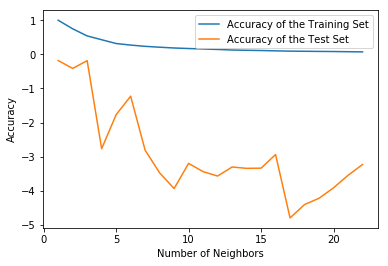

In [78]:
plt.plot(n_neighbors_range, training_accuracy, label='Accuracy of the Training Set')
plt.plot(n_neighbors_range, testing_accuracy, label='Accuracy of the Test Set')
plt.ylabel('Accuracy')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()

__Visualizing Mean Absolute Error__

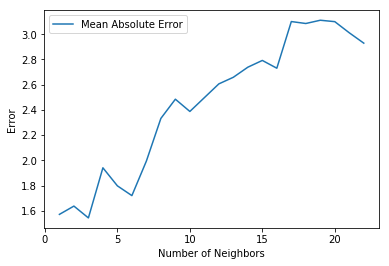

In [79]:
plt.plot(n_neighbors_range, errors, label='Mean Absolute Error')
plt.ylabel('Error')
plt.xlabel('Number of Neighbors')
plt.legend()
plt.show()

In [80]:
testing_accuracy

[-0.17985634456850508,
 -0.4117805120110605,
 -0.18443588909649922,
 -2.7654733712097683,
 -1.7672684472245392,
 -1.225632386681986,
 -2.8093484940163154,
 -3.4718004730652208,
 -3.9328979095989114,
 -3.194962483704198,
 -3.437116229894732,
 -3.5657367731301948,
 -3.300768911068487,
 -3.3402687583870008,
 -3.334618070881466,
 -2.9366067737956065,
 -4.792934447769129,
 -4.400891281459904,
 -4.217128846116529,
 -3.910645710029592,
 -3.545061167566982,
 -3.2266264329849017]

Larger negative scores indicate worsening model performance as the number of neighbors increases. We can use the n_neighbors value that produces the highest score `(k=1)` for evaluating our final model...

In [81]:
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_pog_train, y_pog_train)
train_acc = knn.score(X_pog_train, y_pog_train)
test_acc = knn.score(X_pog_test, y_pog_test)
error = mae(y_pog_test, knn.predict(X_pog_test))

In [82]:
print('\n\nK-Nearest Neighbors Model for Predicting Continuous Percent_of_Goal')
print('=======================================================================')
print('Parameters:\nk = 1')
print('\nError:\nMean Absolute Error (MAE) = {:.5f}'.format(error))
print('\nAccuracy:\nTraining Accuracy = {:.5f}%\nTesting Accuracy = {:.5f}%\n\n'.format(train_acc*100, 
                                                                                        test_acc*100))



K-Nearest Neighbors Model for Predicting Continuous Percent_of_Goal
Parameters:
k = 1

Error:
Mean Absolute Error (MAE) = 1.57119

Accuracy:
Training Accuracy = 100.00000%
Testing Accuracy = -17.98563%




### Stochastic Gradient Descent (SGD) Regressor

In [98]:
# Generate range of alphas for grid search
gscv_alphas = []
for i in range(1, 100): gscv_alphas.append(i/100)
for i in range(10, 101): gscv_alphas.append(i/10)

In [99]:
# Find optimal SGD parameters using GridSearchCV
param_grid = {'penalty': ['l1', 'l2'], 'alpha': gscv_alphas}
grid = GridSearchCV(SGDRegressor(), param_grid, cv=5)
grid.fit(X_pog_train, np.ravel(y_pog_train))
best_params = grid.best_params_

In [100]:
# Find optimal l1_ratio ('Elastic Net mixing parameter') for SGD Regression
l1_range = [.1, 0.45, .5, .7, 0.85, .9, .95, .99, 1]
elasto = ElasticNetCV(l1_ratio=l1_range, max_iter=10000)
elasto.fit(X_pog_train, np.ravel(y_pog_train))

ElasticNetCV(alphas=None, copy_X=True, cv='warn', eps=0.001,
       fit_intercept=True,
       l1_ratio=[0.1, 0.45, 0.5, 0.7, 0.85, 0.9, 0.95, 0.99, 1],
       max_iter=10000, n_alphas=100, n_jobs=None, normalize=False,
       positive=False, precompute='auto', random_state=None,
       selection='cyclic', tol=0.0001, verbose=0)

In [101]:
print('Optimal Values for SGD Parameters:\nalpha = {}\npenalty = {}\nl1_ratio = {}'
      .format(best_params.get('alpha'), best_params.get('penalty'), elasto.l1_ratio_))

Optimal Values for SGD Parameters:
alpha = 0.5
penalty = l2
l1_ratio = 0.1


In [102]:
# Apply the model to our training set using the above optimal parameters
sgd = SGDRegressor(alpha=best_params.get('alpha'), penalty=best_params.get('penalty'), l1_ratio=elasto.l1_ratio_)
sgd.fit(X_pog_train, np.ravel(y_pog_train))
sgd_yhat = sgd.predict(X_pog_test)
sgd_mae = mae(y_pog_test, sgd_yhat)

In [142]:
# Train, test accuracies
sgd_train_acc = sgd.score(X_pog_train, y_pog_train)
sgd_test_acc = sgd.score(X_pog_test, y_pog_test)

In [144]:
print('Optimal Values for SGD Parameters:\nalpha = {}\npenalty = {}\nl1_ratio = {}'
      .format(best_params.get('alpha'), best_params.get('penalty'), elasto.l1_ratio_))
print('\nSGD Regression:')
print('---------------')
print('Training Accuracy = {:.5f}%'.format(sgd_train_acc))
print('Testing Accuracy = {:.5f}%'.format(sgd_test_acc))
print('Mean Absolute Error (MAE) = {:.5f}'.format(sgd_mae))

Optimal Values for SGD Parameters:
alpha = 0.5
penalty = l2
l1_ratio = 0.1

SGD Regression:
---------------
Training Accuracy = 0.00016%
Testing Accuracy = 0.09388%
Mean Absolute Error (MAE) = 1.29448


The mean absolute error of this model is relatively high, indicating a poor fit to the data. The model, as it is, will likely not make accurate predictions on novel data. I had tried multivariate regression (using ordinary least squares) earlier but ended up with a MAE of __8.89__, which is extremely high. That model was an even poorer fit to the data, so I tried SGDRegressor. I can try Lasso and Ridge regression models to see if my data can support an even better fitting model... 

### Ridge Regressor

In [131]:
def optimal_alpha(alg, alphas, X, y):
    '''Applies a version of the specified regression algorithm 
    with built-in cross-validation, using a range of alphas, 
    to determine the optimal one.'''
    if (alg == 'Ridge'):
        ridge_cv = RidgeCV(alphas)
        model_cv = ridge_cv.fit(X, y)
    if (alg == 'Lasso'):
        lasso_cv = LassoCV(alphas=alphas, cv=5)
        model_cv = lasso_cv.fit(X, y)
    return model_cv.alpha_

In [132]:
# Create a range of testable alpha's (regularization parameter):
alpha_range = []
for i in range(1, 101):
    alpha_range.append(i/10)

In [133]:
# Find the optimal alpha for this dataset
alpha = optimal_alpha('Ridge', alpha_range, X_pct, np.ravel(y_pct))

In [141]:
# Perform 5-Fold CV
pog_cv_ridge = KFold(n_splits=5)
for train_index, test_index in pog_cv_ridge.split(X_pct):
    cv_X_train, cv_X_test = X_pct[train_index], X_pct[test_index]
    cv_y_train, cv_y_test = y_pct[train_index], y_pct[test_index]

# Fit the Ridge Regression model using our optimal alpha
ridge_model = Ridge(alpha).fit(cv_X_train, cv_y_train)
ridge_yhat = ridge_model.predict(cv_X_test)
ridge_train_acc = ridge_model.score(cv_X_train, cv_y_train)
ridge_test_acc = ridge_model.score(cv_X_test, cv_y_test)

# Calculate MAE
ridge_mae = mae(cv_y_test, ridge_yhat)
print('Optimal Alpha: {}'.format(alpha))
print('Ridge Regression:')
print('-----------------')
print('Training Accuracy = {:.5f}%'.format(ridge_train_acc))
print('Testing Accuracy = {:.5f}%'.format(ridge_test_acc))
print('Mean Absolute Error (MAE) = {:.5f}'.format(ridge_mae))

Optimal Alpha: 1.0
Ridge Regression:
-----------------
Training Accuracy = 0.00230%
Testing Accuracy = 0.00126%
Mean Absolute Error (MAE) = 9.45743


### Lasso Regressor

In [138]:
# Find the optimal alpha for this dataset
alpha = optimal_alpha('Lasso', alpha_range, X_pct, np.ravel(y_pct))

In [ ]:
# Fit the Lasso Regression model using our optimal alpha
lasso_model = Lasso(alpha).fit(cv_X_train, cv_y_train)
lasso_yhat = lasso_model.predict(cv_X_test)

# Calculate MAE
lasso_mae = mae(cv_y_test, lasso_yhat)

In [145]:
# Train, test accuracies
lasso_train_acc = lasso_model.score(cv_X_train, cv_y_train)
lasso_test_acc = lasso_model.score(cv_X_test, cv_y_test)

print('Optimal Alpha: {}'.format(alpha))
print('Lasso Regression:')
print('-----------------')
print('Training Accuracy = {:.5f}%'.format(lasso_train_acc))
print('Testing Accuracy = {:.5f}%'.format(lasso_test_acc))
print('Mean Absolute Error (MAE) = {:.5f}\n\n'.format(lasso_mae))

Optimal Alpha: 1.0
Lasso Regression:
-----------------
Training Accuracy = 0.00044%
Testing Accuracy = 0.00091%
Mean Absolute Error (MAE) = 5.07089




__Discussion of Results__

Out of the 4 preceding models, the one with the lowest mean absolute error was SGD Regression, at 1.29448. All models had very similar accuracies, in that their accuracies were all under 1% for both training and testing sets.

When I embarked on this stage of the analysis, I tried KNN Regression first, since I had had success with KNN Classification during outcome prediction. This yielded quite poor model performance. I then tried regression via stochastic gradient descent, which yielded a much lower error rate of just above 1.0. Attempting to achieve even lower error between actual and predicted y values, I tried modeling the data using Ridge and Lasso Regression algorithms like in the homework assignments. The mean absolute error for Lasso was second-best at just over 5.0, while the Ridge regression error was comparable to KNN, at just over 9.4. Overall, the best model was SGDRegressor, and even though the accuracies for training and testing were low on all models, SGD produced the lowest error among the models that I tested.

One potential reason for the poor performance of the regression models to predict `pct_of_goal` could be that the distribution of this target variable is heavily skewed right. From my research, the overwhelming majority of Kickstarter campaigns fail, with a large portion of them receiving very few or no pledges. This bias in the model would favor significant mislabeling of predictions, resulting in poor generalizability to new data.

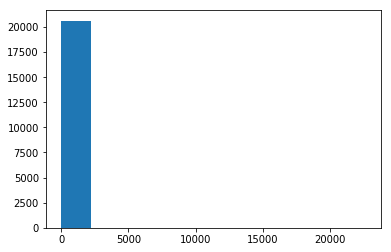

In [160]:
ks_pog = ks['pct_of_goal']
plt.hist(ks_pog.values)
plt.show()

---